In [3]:
import pandas as pd
from Bio import SeqIO
import io

In [5]:
# Load CATH domain classification data
df = pd.read_csv('../data/cath-classification-data/cath-domain-list-S100.txt', 
                 sep=r'\s+', comment='#', engine='python',
                 names=['domain_name', 'class_number', 'architecture_number', 'topology_number',
                        'homologous_superfamily_number', 's35_sequence_cluster_number',
                        's60_sequence_cluster_number', 's95_sequence_cluster_number',
                        's100_sequence_cluster_number', 's100_sequence_count_number',
                        'domain_length', 'structure_resolution'])

# Create CATH code (class.architecture.topology.homologous_superfamily)
df['cath_code'] = (df['class_number'].astype(str) + '.' + 
                   df['architecture_number'].astype(str) + '.' + 
                   df['topology_number'].astype(str) + '.' + 
                   df['homologous_superfamily_number'].astype(str))

def load_fasta_to_dataframe(fasta_file):
    """Load FASTA file into a pandas DataFrame with sequence headers and sequences."""
    sequences = []
    headers = []
    
    with open(fasta_file, 'r') as handle:
        for record in SeqIO.parse(handle, "fasta"):
            headers.append(record.id)
            sequences.append(str(record.seq))
    
    return pd.DataFrame({
        'header': headers,
        'sequence': sequences
    })

# Load the CATH domain sequences - main sequence datasets
seq_df_100 = load_fasta_to_dataframe('../data/sequence-data/cath-domain-seqs-S100.fa')

# Save domain to CATH code mapping
df[['domain_name', 'cath_code']].to_csv('../data/cath-domain-sf-list.txt', 
                                        sep='\t', header=False, index=False)

print(f"Loaded {len(df)} CATH domain entries")
df.head()


Loaded 123251 CATH domain entries


,domain_name,class_number,architecture_number,topology_number,homologous_superfamily_number,s35_sequence_cluster_number,s60_sequence_cluster_number,s95_sequence_cluster_number,s100_sequence_cluster_number,s100_sequence_count_number,domain_length,structure_resolution,cath_code
0,1oaiA00,1,10,8,10,1,1,1,1,1,59,1.00,1.10.8.10
1,3frhA01,1,10,8,10,2,1,1,1,1,58,1.20,1.10.8.10
2,3b89A01,1,10,8,10,2,1,1,2,1,54,2.60,1.10.8.10
3,6pi9A01,1,10,8,10,2,2,1,1,1,59,1.85,1.10.8.10
4,4g3oA00,1,10,8,10,3,1,1,1,1,53,1.60,1.10.8.10


In [6]:


def load_fasta_to_dataframe(fasta_file):
    """Load FASTA file into a pandas DataFrame with sequence headers and sequences."""
    sequences = []
    headers = []
    
    with open(fasta_file, 'r') as handle:
        for record in SeqIO.parse(handle, "fasta"):
            headers.append(record.id)
            sequences.append(str(record.seq))
    
    return pd.DataFrame({
        'header': headers,
        'sequence': sequences
    })

# Load the CATH domain sequences - main sequence datasets
seq_df_100 = load_fasta_to_dataframe('../data/sequence-data/cath-domain-seqs-S100.fa')
seq_df_95 = load_fasta_to_dataframe('../data/sequence-data/cath-domain-seqs-S95.fa')
seq_df_60 = load_fasta_to_dataframe('../data/sequence-data/cath-domain-seqs-S60.fa')
seq_df_35 = load_fasta_to_dataframe('../data/sequence-data/cath-domain-seqs-S35.fa')

# Load the non-redundant datasets separately
seq_df_40 = load_fasta_to_dataframe('../data/non-redundant-data-sets/cath-dataset-nonredundant-S40.fa')
seq_df_20 = load_fasta_to_dataframe('../data/non-redundant-data-sets/cath-dataset-nonredundant-S20.fa')

print("Main sequence datasets:")
print(f"Loaded {len(seq_df_100)} sequences from s100 FASTA file")
print(f"Loaded {len(seq_df_95)} sequences from s95 FASTA file")
print(f"Loaded {len(seq_df_60)} sequences from s60 FASTA file")
print(f"Loaded {len(seq_df_35)} sequences from s35 FASTA file")

print("\nNon-redundant datasets:")
print(f"Loaded {len(seq_df_40)} sequences from s40 FASTA file")
print(f"Loaded {len(seq_df_20)} sequences from s20 FASTA file")

def extract_domain_id(header):
    """Extract domain ID from FASTA header (e.g., 'cath|4_4_0|101mA00/0-153' -> '101mA00')"""
    if '|' in header:
        return header.split('|')[2].split('/')[0]
    return header.split('/')[0]

# Extract domain IDs from main sequence datasets
domains_100 = set(seq_df_100['header'].apply(extract_domain_id))
domains_95 = set(seq_df_95['header'].apply(extract_domain_id))
domains_60 = set(seq_df_60['header'].apply(extract_domain_id))
domains_35 = set(seq_df_35['header'].apply(extract_domain_id))

# Extract domain IDs from non-redundant datasets
domains_40 = set(seq_df_40['header'].apply(extract_domain_id))
domains_20 = set(seq_df_20['header'].apply(extract_domain_id))

print("\nChecking subset relationships for main sequence datasets:")
print(f"S95 ⊆ S100: {domains_95.issubset(domains_100)} ({len(domains_95)} ⊆ {len(domains_100)})")
print(f"S60 ⊆ S95:  {domains_60.issubset(domains_95)} ({len(domains_60)} ⊆ {len(domains_95)})")
print(f"S35 ⊆ S60:  {domains_35.issubset(domains_60)} ({len(domains_35)} ⊆ {len(domains_60)})")

print("\nChecking subset relationships for non-redundant datasets:")
print(f"S20 ⊆ S40:  {domains_20.issubset(domains_40)} ({len(domains_20)} ⊆ {len(domains_40)})")
print(f"S20 ⊆ S100: {domains_20.issubset(domains_100)} ({len(domains_20)} ⊆ {len(domains_100)})")
print(f"S40 ⊆ S100: {domains_40.issubset(domains_100)} ({len(domains_40)} ⊆ {len(domains_100)})")

print("\nChecking relationships between main and non-redundant datasets:")
print(f"S40 ⊆ S60:  {domains_40.issubset(domains_60)} ({len(domains_40)} ⊆ {len(domains_60)})")
print(f"S20 ⊆ S35:  {domains_20.issubset(domains_35)} ({len(domains_20)} ⊆ {len(domains_35)})")

# Show any domains that break the subset relationship for main datasets
if not domains_95.issubset(domains_100):
    diff = domains_95 - domains_100
    print(f"\nDomains in S95 but not S100: {len(diff)} domains")
    print(f"Examples: {list(diff)[:5]}")
if not domains_60.issubset(domains_95):
    diff = domains_60 - domains_95
    print(f"Domains in S60 but not S95: {len(diff)} domains")
    print(f"Examples: {list(diff)[:5]}")
if not domains_35.issubset(domains_60):
    diff = domains_35 - domains_60
    print(f"Domains in S35 but not S60: {len(diff)} domains")
    print(f"Examples: {list(diff)[:5]}")

# Show any domains that break the subset relationship for non-redundant datasets
if not domains_20.issubset(domains_40):
    diff = domains_20 - domains_40
    print(f"\nDomains in S20 but not S40: {len(diff)} domains")
    print(f"Examples: {list(diff)[:5]}")
if not domains_40.issubset(domains_100):
    diff = domains_40 - domains_100
    print(f"Domains in S40 but not S100: {len(diff)} domains")
    print(f"Examples: {list(diff)[:5]}")
if not domains_20.issubset(domains_100):
    diff = domains_20 - domains_100
    print(f"Domains in S20 but not S100: {len(diff)} domains")
    print(f"Examples: {list(diff)[:5]}")

# Show any domains that break the cross-dataset relationships
if not domains_40.issubset(domains_100):
    diff = domains_40 - domains_100
    print(f"\nDomains in S40 but not S100: {len(diff)} domains")
    print(f"Examples: {list(diff)[:5]}")
if not domains_20.issubset(domains_100):
    diff = domains_20 - domains_100
    print(f"Domains in S20 but not S100: {len(diff)} domains")
    print(f"Examples: {list(diff)[:5]}")


Main sequence datasets:
Loaded 123251 sequences from s100 FASTA file
Loaded 73535 sequences from s95 FASTA file
Loaded 52974 sequences from s60 FASTA file
Loaded 37350 sequences from s35 FASTA file

Non-redundant datasets:
Loaded 34653 sequences from s40 FASTA file
Loaded 15043 sequences from s20 FASTA file

Checking subset relationships for main sequence datasets:
S95 ⊆ S100: True (73535 ⊆ 123251)
S60 ⊆ S95:  True (52974 ⊆ 73535)
S35 ⊆ S60:  True (37350 ⊆ 52974)

Checking subset relationships for non-redundant datasets:
S20 ⊆ S40:  False (15043 ⊆ 34653)
S20 ⊆ S100: True (15043 ⊆ 123251)
S40 ⊆ S100: True (34653 ⊆ 123251)

Checking relationships between main and non-redundant datasets:
S40 ⊆ S60:  False (34653 ⊆ 52974)
S20 ⊆ S35:  False (15043 ⊆ 37350)

Domains in S20 but not S40: 4486 domains
Examples: ['2m60A00', '4dmoA00', '3rfzB01', '4icvA00', '4arsA02']


In [16]:
# Load train, val, and test sets from clustered datasets
from pathlib import Path

def load_fasta_to_df(fasta_path, split_name):
    """Load a FASTA file into a DataFrame with header, sequence, length, and split columns."""
    records = []
    with open(fasta_path, 'r') as f:
        header = None
        sequence = []
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if header is not None:
                    seq = ''.join(sequence)
                    # Extract domain_id from header (format: cath|4_4_0|107lA00/1-162)
                    domain_id = header.split('|')[2].split('/')[0] if '|' in header else None
                    records.append({
                        'header': header,
                        'domain_id': domain_id,
                        'sequence': seq,
                        'seq_length': len(seq),
                        'split': split_name
                    })
                header = line[1:]  # Remove '>' prefix
                sequence = []
            else:
                sequence.append(line)
        # Don't forget the last sequence
        if header is not None:
            seq = ''.join(sequence)
            # Extract domain_id from header (format: cath|4_4_0|107lA00/1-162)
            domain_id = header.split('|')[2].split('/')[0] if '|' in header else None
            records.append({
                'header': header,
                'domain_id': domain_id,
                'sequence': seq,
                'seq_length': len(seq),
                'split': split_name
            })
    return pd.DataFrame(records)

# Define base path
base_path = Path('../data/clustered_datasets')

# Load train and val sets
train_df = load_fasta_to_df(base_path / 'train.fasta', 'train')
val_df = load_fasta_to_df(base_path / 'val.fasta', 'val')

# Load test sets for s10 through s90
test_dfs = []
for identity in [10, 20, 30, 40, 50, 60, 70, 80, 90]:
    test_path = base_path / f's{identity}' / 'test.fasta'
    if test_path.exists():
        test_df = load_fasta_to_df(test_path, f's{identity}_test')
        test_dfs.append(test_df)
        print(f"Loaded {len(test_df)} sequences from {test_path}")

# Combine all dataframes
all_splits_df = pd.concat([train_df, val_df] + test_dfs, ignore_index=True)

# Load CATH domain superfamily list
cath_sf_path = Path('../data/cath-domain-sf-list.txt')
cath_sf_df = pd.read_csv(cath_sf_path, sep='\t', header=None, names=['domain_id', 'cath_code'])

# Left join with CATH superfamily data
all_splits_df = all_splits_df.merge(cath_sf_df, on='domain_id', how='left')

print(f"\nTotal sequences loaded: {len(all_splits_df)}")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test (all): {sum(len(df) for df in test_dfs)}")
print("\nSplit distribution:")
print(all_splits_df['split'].value_counts().sort_index())

# Check how many sequences have CATH codes
print(f"\nSequences with CATH codes: {all_splits_df['cath_code'].notna().sum()}/{len(all_splits_df)}")

# Display sample
print("\nSample of loaded data:")
all_splits_df.head()


Loaded 669 sequences from ../data/clustered_datasets/s10/test.fasta
Loaded 714 sequences from ../data/clustered_datasets/s20/test.fasta
Loaded 849 sequences from ../data/clustered_datasets/s30/test.fasta
Loaded 1155 sequences from ../data/clustered_datasets/s40/test.fasta
Loaded 1475 sequences from ../data/clustered_datasets/s50/test.fasta
Loaded 1793 sequences from ../data/clustered_datasets/s60/test.fasta
Loaded 2089 sequences from ../data/clustered_datasets/s70/test.fasta
Loaded 2407 sequences from ../data/clustered_datasets/s80/test.fasta
Loaded 2815 sequences from ../data/clustered_datasets/s90/test.fasta

Total sequences loaded: 94820
Train: 78989, Val: 1865, Test (all): 13966

Split distribution:
split
s10_test      669
s20_test      714
s30_test      849
s40_test     1155
s50_test     1475
s60_test     1793
s70_test     2089
s80_test     2407
s90_test     2815
train       78989
val          1865
Name: count, dtype: int64

Sequences with CATH codes: 94820/94820

Sample of loaded

,header,domain_id,sequence,seq_length,split,cath_code
0,cath|4_4_0|12asA00/4-330,12asA00,MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQD...,330,train,3.30.930.10
1,cath|4_4_0|12e8H01/1-113,12e8H01,EVQLQQSGAEVVRSGASVKLSCTASGFNIKDYYIHWVKQRPEKGLE...,120,train,2.60.40.10
2,cath|4_4_0|12e8L01/1-107,12e8L01,DIVMTQSQKFMSTSVGDRVSITCKASQNVGTAVAWYQQKPGQSPKL...,107,train,2.60.40.10
3,cath|4_4_0|12e8L02/108-211,12e8L02,RADAAPTVSIFPPSSEQLTSGGASVVCFLNNFYPKDINVKWKIDGS...,104,train,2.60.40.10
4,cath|4_4_0|155cA00/1-134,155cA00,XNEGDAAKGEKEFNKCKACHMIQAPDGTDIKGGKTGPNLYGVVGRK...,135,train,1.10.760.10


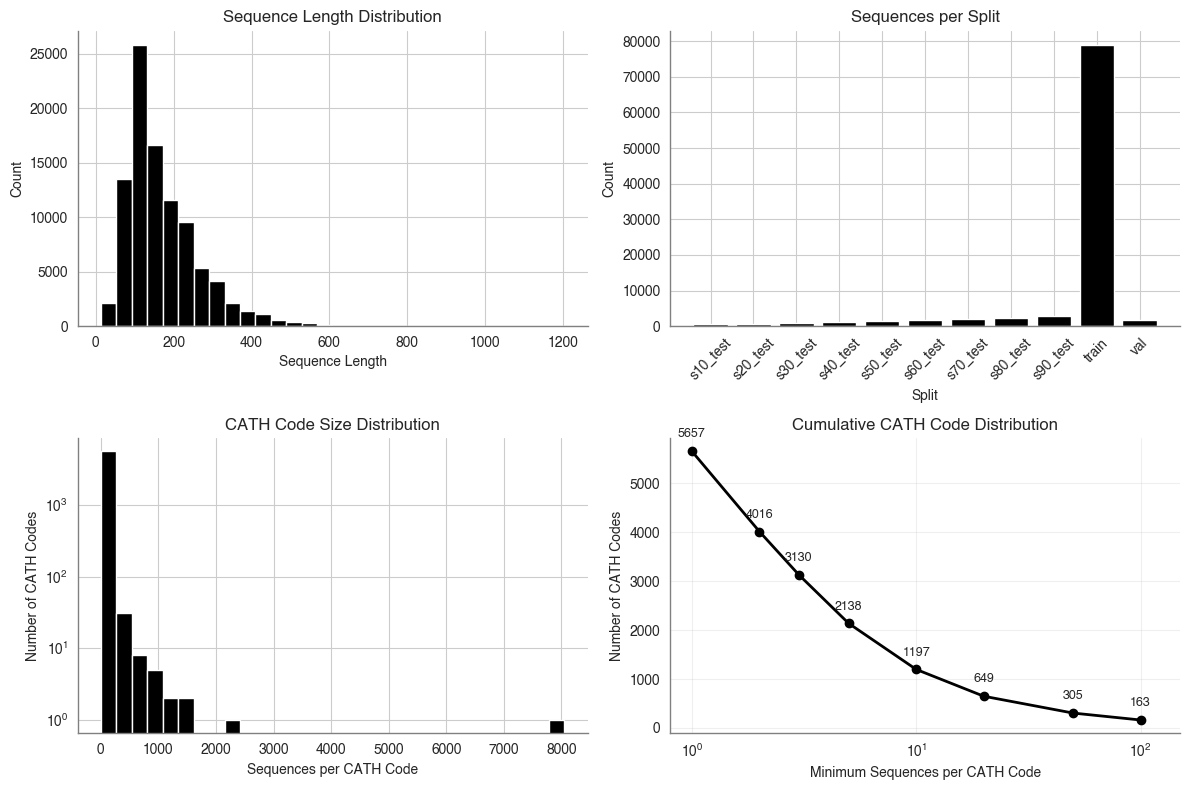


CATH Code Size Statistics:
Total unique CATH codes: 5657
CATH codes with ≥1 sequences: 5657
CATH codes with ≥2 sequences: 4016
CATH codes with ≥3 sequences: 3130
CATH codes with ≥5 sequences: 2138
CATH codes with ≥10 sequences: 1197


In [20]:
import matplotlib.pyplot as plt

# Simple Helvetica style
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Sequence length distribution
axes[0, 0].hist(all_splits_df['seq_length'], bins=30, color='black')
axes[0, 0].set_xlabel('Sequence Length')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Sequence Length Distribution')

# 2. Split distribution
split_counts = all_splits_df['split'].value_counts().sort_index()
axes[0, 1].bar(range(len(split_counts)), split_counts.values, color='black')
axes[0, 1].set_xticks(range(len(split_counts)))
axes[0, 1].set_xticklabels(split_counts.index, rotation=45)
axes[0, 1].set_xlabel('Split')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Sequences per Split')

# 3. CATH superfamily size distribution
cath_sizes = all_splits_df['cath_code'].value_counts()
axes[1, 0].hist(cath_sizes.values, bins=30, color='black')
axes[1, 0].set_xlabel('Sequences per CATH Code')
axes[1, 0].set_ylabel('Number of CATH Codes')
axes[1, 0].set_title('CATH Code Size Distribution')
axes[1, 0].set_yscale('log')

# 4. CATH code size thresholds - improved visualization
size_thresholds = [1, 2, 3, 5, 10, 20, 50, 100]
threshold_counts = [(cath_sizes >= threshold).sum() for threshold in size_thresholds]

# Create a more informative plot with cumulative distribution
axes[1, 1].plot(size_thresholds, threshold_counts, 'o-', color='black', linewidth=2, markersize=6)
axes[1, 1].set_xlabel('Minimum Sequences per CATH Code')
axes[1, 1].set_ylabel('Number of CATH Codes')
axes[1, 1].set_title('Cumulative CATH Code Distribution')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0.8, 150)

# Add value annotations on the plot
for i, (x, y) in enumerate(zip(size_thresholds, threshold_counts)):
    axes[1, 1].annotate(f'{y}', (x, y), textcoords="offset points", 
                       xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print statistics
print("\nCATH Code Size Statistics:")
print(f"Total unique CATH codes: {len(cath_sizes)}")
print(f"CATH codes with ≥1 sequences: {(cath_sizes >= 1).sum()}")
print(f"CATH codes with ≥2 sequences: {(cath_sizes >= 2).sum()}")
print(f"CATH codes with ≥3 sequences: {(cath_sizes >= 3).sum()}")
print(f"CATH codes with ≥5 sequences: {(cath_sizes >= 5).sum()}")
print(f"CATH codes with ≥10 sequences: {(cath_sizes >= 10).sum()}")